In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

import kind
import ex_duffing
import util_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/dreamer',
        '--file_name', 'duffing',
        '--data_nsample', '3848',
        '--feature_ndim', '4',
        '--target_ndim', '2',
        '--data_train_size', '0.8',

        '--lookback_nsample', '384',
        '--forecast_nsample', '192',

        '--batch_size', '128',
        '--nepoch', '200',
        '--patience', '20',
        '--checkpoints', '../../models/dreamer',

        '--seg_nsample_stat', '192',
        '--seg_nsample_trans', '192',
        '--fun_stat', '{"sin": 4, "cos": 4}',
        '--fun_trans', '{"data": 12}',
    ]
)

setpoint = [1.0, 0.0]

In [3]:
model = kind.model(args)

dataset = ex_duffing.dataset(
    args.file_dir, args.file_name, args.file_index, args.file_ext,
    args.data_nsample,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.lookback_nsample, args.forecast_nsample), setpoint, load_normalized=True)

training = kind.training(model)

In [4]:
model.train()
training.fit(dataset)

>>> training nominal mean >>>
	epoch 1 losses: train=0.270125, valid=0.243591, test=0.243807
	validation loss decreased (inf -> 0.243591), saving model ...
	epoch 2 losses: train=0.241582, valid=0.238788, test=0.239031
	validation loss decreased (0.243591 -> 0.238788), saving model ...
	epoch 3 losses: train=0.213424, valid=0.161475, test=0.159400
	validation loss decreased (0.238788 -> 0.161475), saving model ...
	epoch 4 losses: train=0.104109, valid=0.036201, test=0.035209
	validation loss decreased (0.161475 -> 0.036201), saving model ...
	epoch 5 losses: train=0.013336, valid=0.004374, test=0.004445
	validation loss decreased (0.036201 -> 0.004374), saving model ...
	epoch 6 losses: train=0.002716, valid=0.001544, test=0.001548
	validation loss decreased (0.004374 -> 0.001544), saving model ...
	epoch 7 losses: train=0.001111, valid=0.000896, test=0.000861
	validation loss decreased (0.001544 -> 0.000896), saving model ...
	epoch 8 losses: train=0.000704, valid=0.000487, test=0.00

In [5]:
model.eval()
_, _, data_loader = dataset.load(data_type='nom')

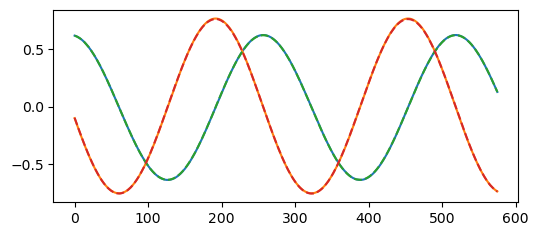

In [6]:
jdata = 2

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_nom = model_o.mean_nom

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(mean_nom[0, :, :2], linestyle='dashed')

        plt.show()

        break


In [7]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training nominal uncertainty >>>
	epoch 1 losses: train=0.112357, valid=0.082785, test=0.082992
	validation loss decreased (inf -> 0.082785), saving model ...
	epoch 2 losses: train=0.080725, valid=0.074191, test=0.074501
	validation loss decreased (0.082785 -> 0.074191), saving model ...
	epoch 3 losses: train=0.053739, valid=0.046293, test=0.046492
	validation loss decreased (0.074191 -> 0.046293), saving model ...
	epoch 4 losses: train=0.045682, valid=0.045278, test=0.045376
	validation loss decreased (0.046293 -> 0.045278), saving model ...
	epoch 5 losses: train=0.045305, valid=0.044988, test=0.045167
	validation loss decreased (0.045278 -> 0.044988), saving model ...
	epoch 6 losses: train=0.044379, valid=0.042312, test=0.042398
	validation loss decreased (0.044988 -> 0.042312), saving model ...
	epoch 7 losses: train=0.041314, valid=0.040987, test=0.041223
	validation loss decreased (0.042312 -> 0.040987), saving model ...
	epoch 8 losses: train=0.040738, valid=0.040740, te

In [8]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

In [9]:
def smoothed_derivative(x, window):
    """
    x: [B, T, 1]
    """
    dx = x[:, 1:, :] - x[:, :-1, :]
    dx = F.pad(dx, (0, 0, 1, 0))

    # Moving average smoothing
    kernel = torch.ones(window, device=x.device) / window
    kernel = kernel.view(1, 1, -1)

    dx = F.conv1d(
        dx.transpose(1, 2),
        kernel,
        padding=window // 2
    ).transpose(1, 2)

    return dx

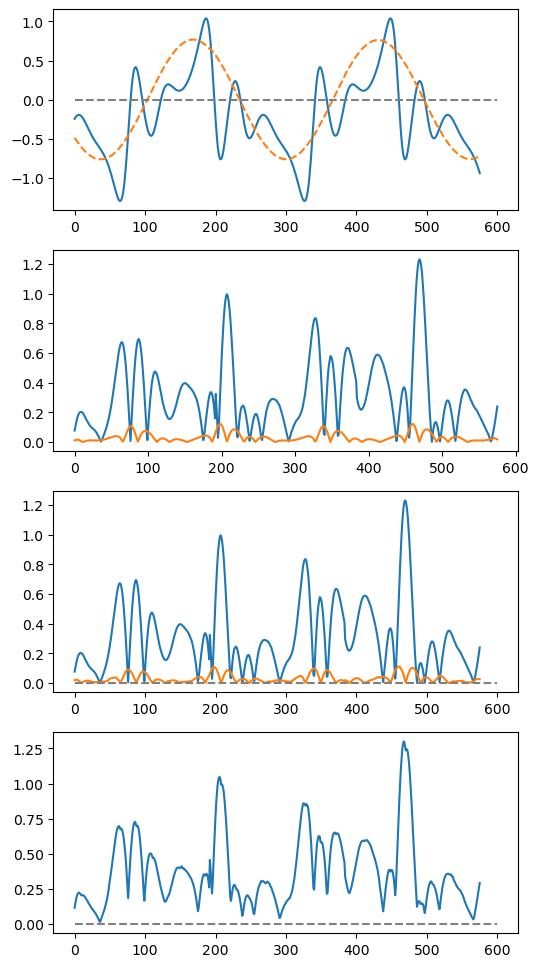

In [10]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_nom
        zeta_nom = model_o.zeta_raw_nom
        signed_error, geometry_error = torch.split(zeta_nom, [2,2], dim=-1)

        a = truth[[jdata], :, 1:2]
        b = stat[[0], :, 1:2]
        slope_a = smoothed_derivative(a, 9)
        slope_b = smoothed_derivative(b, 9)

        value_error = torch.abs(zeta_nom[:, :, 1:2])
        slope_error = torch.abs(slope_a - slope_b)
        beta = 2.0
        geometry_error = torch.abs(geometry_error)
        unsigned_error = torch.abs(signed_error)
        error = unsigned_error + beta * geometry_error

        plt.figure(figsize=(6,12))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, 1:2])
        plt.plot(stat[0, :, 1:2], linestyle='dashed')
        plt.plot([0, 600], [0, 0], linestyle='dashed', color='gray')

        plt.subplot(4,1,2)
        plt.plot(value_error[0, :, :])
        plt.plot(slope_error[0, :, :])

        plt.subplot(4,1,3)
        plt.plot(unsigned_error[0, :, 1:2])
        plt.plot(geometry_error[0, :, 1:2])
        plt.plot([0, 600], [0, 0], linestyle='dashed', color='gray')

        plt.subplot(4,1,4)
        plt.plot(error[0, :, 1])
        plt.plot([0, 600], [0, 0], linestyle='dashed', color='gray')

        plt.show()

        break

#print(tata.shape)

In [11]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion mean >>>
	epoch 1 losses: train=0.359881, valid=0.274183, test=0.275647
	validation loss decreased (inf -> 0.274183), saving model ...
	epoch 2 losses: train=0.222783, valid=0.191547, test=0.192109
	validation loss decreased (0.274183 -> 0.191547), saving model ...
	epoch 3 losses: train=0.188665, valid=0.186104, test=0.186473
	validation loss decreased (0.191547 -> 0.186104), saving model ...
	epoch 4 losses: train=0.185814, valid=0.183455, test=0.183709
	validation loss decreased (0.186104 -> 0.183455), saving model ...
	epoch 5 losses: train=0.180672, valid=0.175808, test=0.175202
	validation loss decreased (0.183455 -> 0.175808), saving model ...
	epoch 6 losses: train=0.168089, valid=0.147471, test=0.146774
	validation loss decreased (0.175808 -> 0.147471), saving model ...
	epoch 7 losses: train=0.130074, valid=0.110551, test=0.109824
	validation loss decreased (0.147471 -> 0.110551), saving model ...
	epoch 8 losses: train=0.087836, valid=0.074080, test=0.

In [12]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

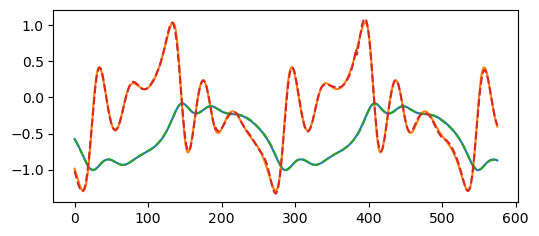

In [13]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_exc

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break

In [14]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion uncertainty >>>
	epoch 1 losses: train=0.149218, valid=0.106144, test=0.106820
	validation loss decreased (inf -> 0.106144), saving model ...
	epoch 2 losses: train=0.081076, valid=0.063510, test=0.064029
	validation loss decreased (0.106144 -> 0.063510), saving model ...
	epoch 3 losses: train=0.060766, valid=0.059176, test=0.059759
	validation loss decreased (0.063510 -> 0.059176), saving model ...
	epoch 4 losses: train=0.059057, valid=0.059162, test=0.059597
	validation loss decreased (0.059176 -> 0.059162), saving model ...
	epoch 5 losses: train=0.058879, valid=0.058761, test=0.059207
	validation loss decreased (0.059162 -> 0.058761), saving model ...
	epoch 6 losses: train=0.058843, valid=0.058792, test=0.059256
	early stopping counter: 1 out of 20
	epoch 7 losses: train=0.058614, valid=0.058463, test=0.058944
	validation loss decreased (0.058761 -> 0.058463), saving model ...
	epoch 8 losses: train=0.058658, valid=0.058661, test=0.059102
	early stopping c

In [15]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

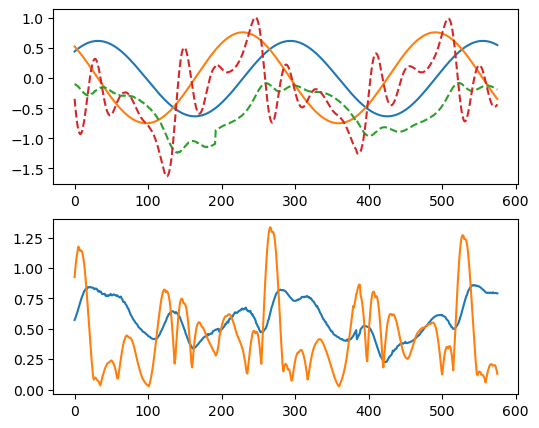

In [16]:
jdata = 2

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        exc = model_o.mean_exc
        exc_u = model_o.zeta_exc

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(exc[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(exc_u[0, :, :2])

        plt.show()

        break

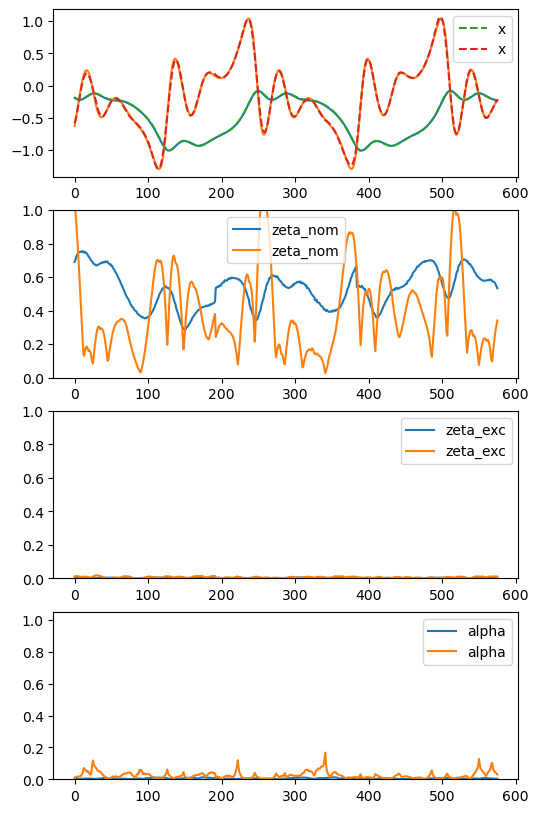

In [17]:
jdata = 11

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        pre = model_o.blend
        u_nom = model_o.zeta_nom
        u_exc = model_o.zeta_exc
        alpha = model_o.alpha

        plt.figure(figsize=(6,10))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(pre[0, :, :2], linestyle='dashed', label='x')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(u_nom[0, :, :2], label='zeta_nom')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(u_exc[0, :, :2], label='zeta_exc')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,4)
        plt.plot(alpha[0, :, :2], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break